# Reconocimiento de dígitos MNIST: NumPy desde cero vs PyTorch

Este notebook resume y compara los resultados de las dos implementaciones
de este proyecto:

1. **`src/scratch/`** — una red neuronal (784→16→16→10) implementada desde
   cero con NumPy: forward pass, backpropagation y descenso de gradiente
   estocástico escritos a mano.
2. **`src/pytorch_version/`** — la misma arquitectura usando PyTorch
   (`nn.Module`, autograd, `torch.optim`).

Proyecto basado en la serie [*Neural Networks* de 3Blue1Brown](https://www.youtube.com/playlist?list=PLZHQObOWTQDNU6R1_67000Dx_ZCJB-3pi)
y el libro [*Neural Networks and Deep Learning* de Michael Nielsen](http://neuralnetworksanddeeplearning.com/).

Este notebook **no reentrena nada** — lee los resultados ya guardados por
`src/scratch/train.py` y `src/pytorch_version/train.py` en la carpeta
`results/`. Si todavía no corriste esos scripts, hazlo primero.

In [1]:
import json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

PROJECT_ROOT = Path.cwd().parent
RESULTS_DIR = PROJECT_ROOT / "results"
DATA_DIR = PROJECT_ROOT / "data"

scratch = np.load(RESULTS_DIR / "scratch_results.npz")
with open(RESULTS_DIR / "pytorch_results.json") as f:
    pytorch = json.load(f)

print("Resultados cargados correctamente.")
print(f"Épocas registradas (NumPy):   {len(scratch['history'])}")
print(f"Épocas registradas (PyTorch): {len(pytorch['history'])}")

Resultados cargados correctamente.
Épocas registradas (NumPy):   30
Épocas registradas (PyTorch): 30


## 1. Precisión final

Comparación directa del resultado que cada versión obtuvo en el set de
test (10,000 imágenes que la red nunca vio durante el entrenamiento).

In [2]:
scratch_final = scratch["history"][-1] * 100
pytorch_final = np.array(pytorch["history"])[-1] * 100

print(f"Versión desde cero (NumPy): {scratch_final:.2f}%")
print(f"Versión PyTorch:            {pytorch_final:.2f}%")
print(f"Diferencia:                 {pytorch_final - scratch_final:.2f} puntos porcentuales")

Versión desde cero (NumPy): 93.72%
Versión PyTorch:            94.13%
Diferencia:                 0.41 puntos porcentuales


## 2. Precisión por época

Cómo fue evolucionando cada versión a lo largo de las 30 épocas de
entrenamiento.

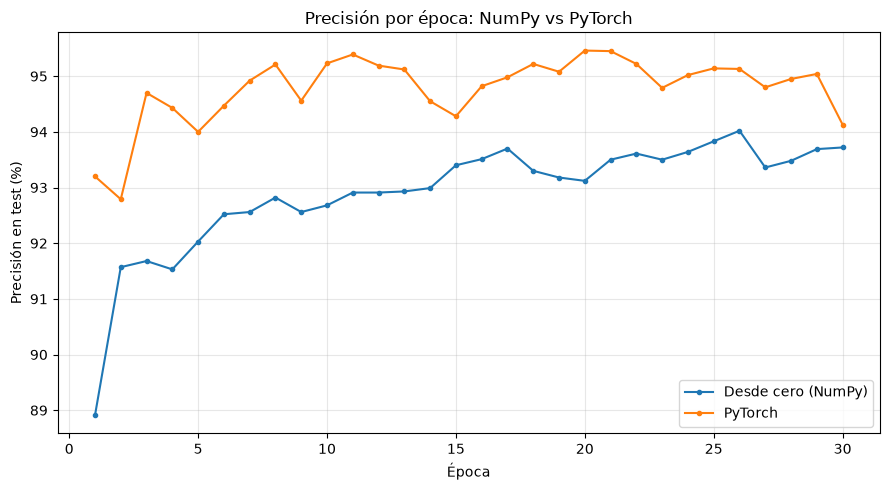

In [3]:
scratch_history = scratch["history"] * 100
pytorch_history = np.array(pytorch["history"]) * 100

plt.figure(figsize=(9, 5))
plt.plot(range(1, len(scratch_history) + 1), scratch_history,
         marker="o", markersize=3, label="Desde cero (NumPy)")
plt.plot(range(1, len(pytorch_history) + 1), pytorch_history,
         marker="o", markersize=3, label="PyTorch")
plt.xlabel("Época")
plt.ylabel("Precisión en test (%)")
plt.title("Precisión por época: NumPy vs PyTorch")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Matriz de confusión (versión PyTorch)

Para cada dígito real (fila), qué dígito predijo la red (columna). La
diagonal son los aciertos; las celdas fuera de la diagonal muestran los
pares que la red confunde con más frecuencia.

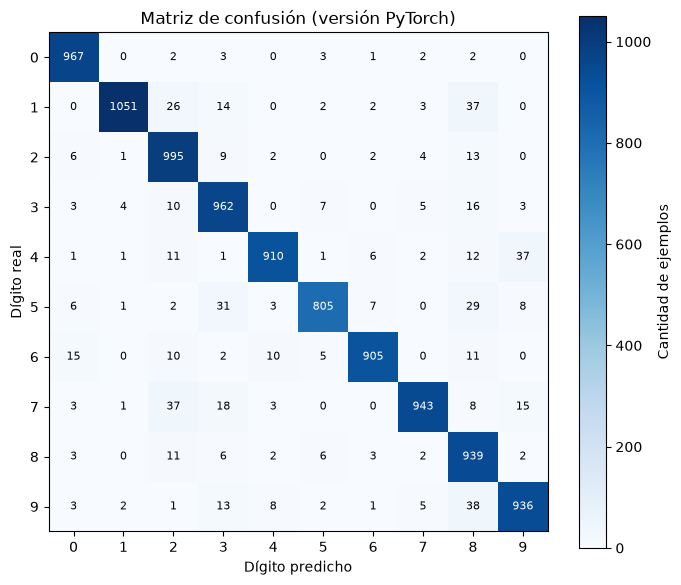

In [4]:
y_true = pytorch["y_true"]
y_pred = pytorch["y_pred"]
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(7, 6))
plt.imshow(cm, cmap="Blues")
plt.colorbar(label="Cantidad de ejemplos")
plt.xticks(range(10))
plt.yticks(range(10))
plt.xlabel("Dígito predicho")
plt.ylabel("Dígito real")
plt.title("Matriz de confusión (versión PyTorch)")

for i in range(10):
    for j in range(10):
        color = "white" if cm[i, j] > cm.max() / 2 else "black"
        plt.text(j, i, str(cm[i, j]), ha="center", va="center",
                  color=color, fontsize=8)

plt.tight_layout()
plt.show()

In [5]:
# Los 5 pares (real, predicho) que más confunde la red, excluyendo la diagonal
off_diagonal = cm.copy()
np.fill_diagonal(off_diagonal, 0)

pairs = []
for i in range(10):
    for j in range(10):
        if off_diagonal[i, j] > 0:
            pairs.append((off_diagonal[i, j], i, j))

pairs.sort(reverse=True)
print("Pares que más confunde la red (real -> predicho):")
for count, real, pred in pairs[:5]:
    print(f"  {real} -> {pred}: {count} veces")

Pares que más confunde la red (real -> predicho):
  9 -> 8: 38 veces
  7 -> 2: 37 veces
  4 -> 9: 37 veces
  1 -> 8: 37 veces
  5 -> 3: 31 veces


## 4. Ejemplos mal clasificados

Imágenes reales de test donde la red PyTorch se equivocó.

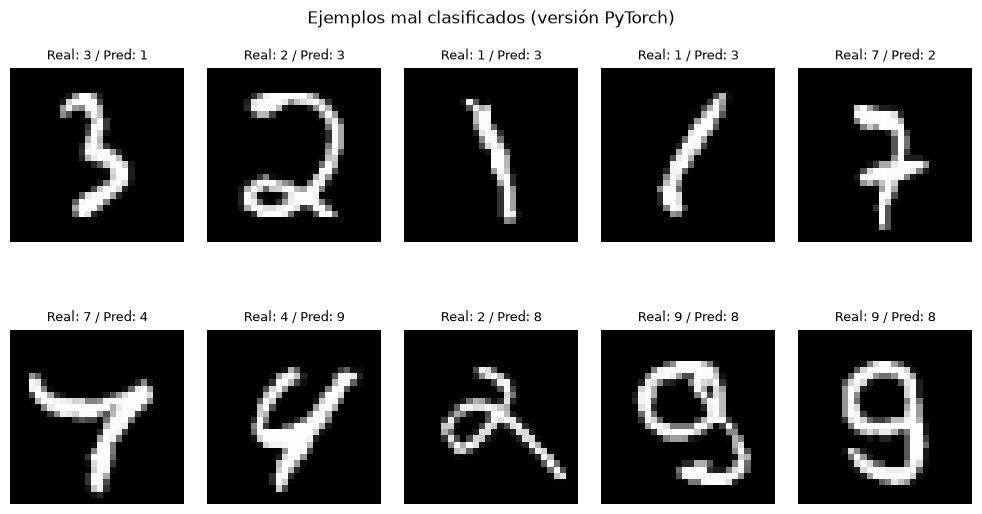

In [6]:
from torchvision import datasets, transforms

y_true_arr = np.array(y_true)
y_pred_arr = np.array(y_pred)
wrong_indices = np.where(y_true_arr != y_pred_arr)[0][:10]

transform = transforms.Compose([transforms.ToTensor()])
test_dataset = datasets.MNIST(root=str(DATA_DIR), train=False,
                                download=True, transform=transform)

cols = 5
rows = (len(wrong_indices) + cols - 1) // cols
plt.figure(figsize=(cols * 2, rows * 2.6))

for i, idx in enumerate(wrong_indices):
    image, _ = test_dataset[idx]
    plt.subplot(rows, cols, i + 1)
    plt.imshow(image.squeeze(), cmap="gray")
    plt.title(f"Real: {y_true_arr[idx]} / Pred: {y_pred_arr[idx]}", fontsize=9)
    plt.axis("off")

plt.suptitle("Ejemplos mal clasificados (versión PyTorch)")
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.subplots_adjust(hspace=0.5)
plt.show()

## 5. Conclusiones

- Ambas versiones implementan el **mismo algoritmo**: forward pass,
  backpropagation y descenso de gradiente estocástico. La versión NumPy
  lo hace explícitamente (cada derivada escrita a mano); la versión
  PyTorch delega el cálculo del gradiente a `autograd` y el ajuste de
  pesos al `optimizer`.
- PyTorch obtuvo una precisión ligeramente mayor, principalmente por usar
  ReLU en lugar de sigmoide y `CrossEntropyLoss` en lugar de error
  cuadrático — no porque el algoritmo de fondo sea distinto.
- Los errores de ambas versiones se concentran en los pares de dígitos
  que son visualmente ambiguos incluso para una persona (4/9, 7/1, 3/5,
  9/8), lo cual es una buena señal: la red está aprendiendo patrones
  reales de forma de trazo, no memorizando ejemplos.
- Posibles próximos pasos: learning rate decay, regularización (dropout
  o L2), una arquitectura convolucional (CNN) en vez de capas totalmente
  conectadas — esta última sería el salto natural desde este proyecto
  hacia visión por computador "moderna".